# Library Imports

In [1]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pprint import pprint

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary

# Files & Directories

In [2]:
# Paths and Directory
SAMPLE_SUBMISSION_PTH = "/kaggle/input/competitions/plant-leaves-super-resolution-challenge/sample_submission.csv"
VGG19_WEIGHTS_PTH = "/kaggle/input/competitions/plant-leaves-super-resolution-challenge/vgg19_weights.pth"
TRAIN_LOW_RES_DIR = "/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_Low_Resolution/"
TRAIN_HIGH_RES_DIR = "/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_High_Resolution/"
TEST_LOW_RES_DIR = "/kaggle/input/competitions/plant-leaves-super-resolution-challenge/test_Low_Resolution/"

# Library Versioning

In [3]:
# Check util ver.
print("UTILS VERSION INFO")
print('='*60)
print(f"Numpy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print('-'*60)


print("PYTORCH VERSION INFO")
print('='*60)
# Setting manual seed for PyTorch
torch.manual_seed(10)
torch.cuda.manual_seed(10)
# Checking for CUDA and PyTorch ver.
print(f"PyTorch Version: {torch.__version__}")
# Display CUDA availablity for Hardware Acceleration
cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")
if cuda_available:
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"Available GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Set default device for tensor operations
device = "cuda" if cuda_available else "cpu"
print(f"Device: {device}")

UTILS VERSION INFO
Numpy: 2.0.2
Pandas: 2.3.3
------------------------------------------------------------
PYTORCH VERSION INFO
PyTorch Version: 2.10.0+cu128
CUDA Available: True
CUDA Version: 12.8
Available GPU: Tesla T4
GPU Memory: 15.6 GB
Device: cuda


# Image Sampling

In [4]:
# Getting image paths from directories
train_lr_img = sorted(glob.glob(os.path.join(TRAIN_LOW_RES_DIR, "*.png")))
train_hr_img = sorted(glob.glob(os.path.join(TRAIN_HIGH_RES_DIR, "*.png")))
test_lr_img = sorted(glob.glob(os.path.join(TEST_LOW_RES_DIR, "*.png")))

print("\nIMAGE SAMPLE SIZE")
print("="*60)
print("Train:")
print(f"- Train LR: {len(train_lr_img)}")
print(f"- Train HR: {len(train_hr_img)}")
print("Test:")
print(f"- Test LR: {len(test_lr_img)}")
print('-'*60)


IMAGE SAMPLE SIZE
Train:
- Train LR: 1642
- Train HR: 1642
Test:
- Test LR: 495
------------------------------------------------------------


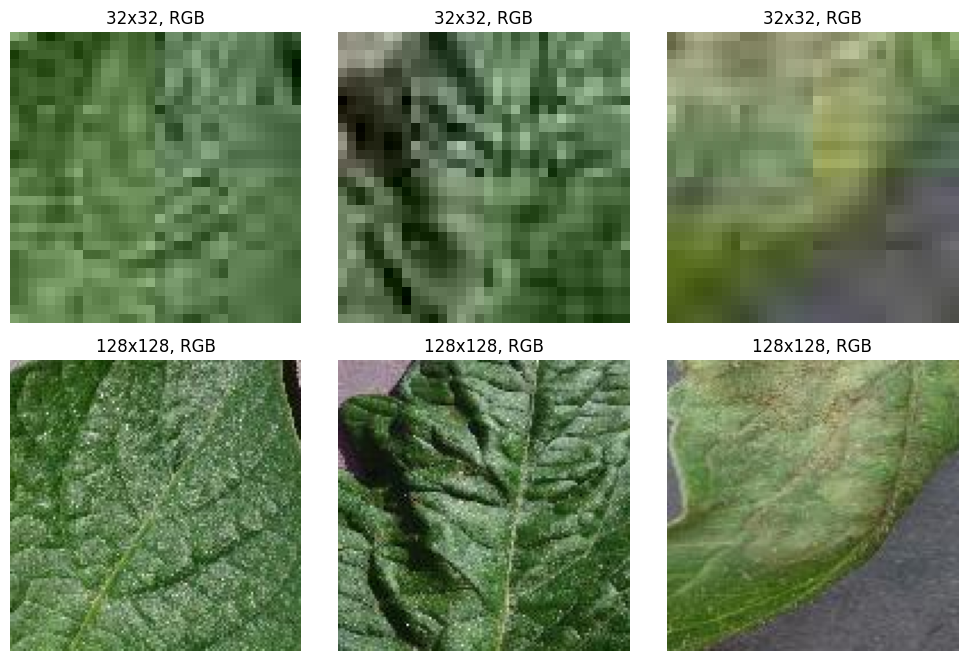

In [5]:
# Visualiztion of leaves
sample_size = 3
plt.figure(figsize=(10, 10))

for i in range(sample_size):
    img = Image.open(train_lr_img[i])
    height, width = img.size

    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(f"{height}x{width}, {img.mode}")
    plt.axis('off')

for i in range(sample_size, 2*sample_size):
    img = Image.open(train_hr_img[i-sample_size])
    height, width = img.size

    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(f"{height}x{width}, {img.mode}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Image Dataset

In [6]:
# Custom Dataset to handle data
class ImageDataset(Dataset):
    def __init__(self, low_res, high_res=None, is_test=False):
        self.low_res = low_res
        self.high_res = high_res
        self.is_test = is_test
        self.to_tensor = T.ToTensor()

    def __len__(self):
        return len(self.low_res)

    def __getitem__(self, idx):
        lr_img_path = self.low_res[idx]
        lr_img = Image.open(lr_img_path)
        if self.is_test:
            name = os.path.basename(lr_img_path)
            return self.to_tensor(lr_img), name
        else:
            hr_img_path = self.high_res[idx]
            hr_img = Image.open(hr_img_path)
            return self.to_tensor(lr_img), self.to_tensor(hr_img)

# Generator

## Residual Block

In [7]:
# Residual Block
class ResidualBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels=ch,
                out_channels=ch,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(num_features=ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels=ch,
                out_channels=ch,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(num_features=ch)   
        )

    def forward(self, x):
        return x + self.block(x)

## Generator Class

In [8]:
class Generator(nn.Module):
    def __init__(self, in_ch=3, base=64, num_res=8):
        super().__init__()
        # Head of the network
        self.head = nn.Sequential(
            nn.Conv2d(
                in_channels=in_ch,
                out_channels=base,
                kernel_size=7,
                stride=1,
                padding=3
            ),
            nn.ReLU(inplace=True)
        )
        # Residual section of the network repeated num_res times
        self.residue = nn.Sequential(*[ResidualBlock(base) for _ in range(num_res)])
        # Upscaling Layer #1
        self.up1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(
                in_channels=base,
                out_channels=base,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(inplace=True)
        )
        # Upscaling Layer #2
        self.up2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(
                in_channels=base,
                out_channels=base//2,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(inplace=True)
        )
        # Tail of Network
        self.tail = nn.Sequential(
            nn.Conv2d(
                in_channels=base//2,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels=32,
                out_channels=3,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.head(x)
        x = self.residue(x)
        x = self.up1(x)
        x = self.up2(x)
        x = self.tail(x)
        return x

# Generator Initialization
G = Generator().to(device)
# Generating Model Summary
summary(model=G, input_size=(1, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
Generator                                [1, 3, 128, 128]          --
├─Sequential: 1-1                        [1, 64, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 64, 32, 32]           9,472
│    └─ReLU: 2-2                         [1, 64, 32, 32]           --
├─Sequential: 1-2                        [1, 64, 32, 32]           --
│    └─ResidualBlock: 2-3                [1, 64, 32, 32]           --
│    │    └─Sequential: 3-1              [1, 64, 32, 32]           74,112
│    └─ResidualBlock: 2-4                [1, 64, 32, 32]           --
│    │    └─Sequential: 3-2              [1, 64, 32, 32]           74,112
│    └─ResidualBlock: 2-5                [1, 64, 32, 32]           --
│    │    └─Sequential: 3-3              [1, 64, 32, 32]           74,112
│    └─ResidualBlock: 2-6                [1, 64, 32, 32]           --
│    │    └─Sequential: 3-4              [1, 64, 32, 32]           74,

# Discriminator

In [9]:
class Discriminator(nn.Module):
    def __init__(self, in_ch=6, base=64):
        super().__init__()
        # Defining block to remove redundant lines
        def block(cin, cout, stride=2, norm=True):
            layers = [nn.Conv2d(
                in_channels=cin,
                out_channels=cout,
                kernel_size=4,
                stride=stride
            )]
            if norm:
                layers.append(nn.BatchNorm2d(cout))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers
        # Main model
        self.model = nn.Sequential(
            *block(in_ch, base, norm=False),
            *block(base, base * 2),
            *block(base*2, base*4),
            *block(base*4, base*8, stride=1),
            nn.Conv2d(
                in_channels=base*8,
                out_channels=1,
                kernel_size=4,
                stride=1,
                padding=1
            )
        )

    def forward(self, lr_up, hr):
        x = torch.concat([lr_up, hr], dim=1)
        return self.model(x)


# Generator Initialization
D = Discriminator().to(device)
# Generating Model Summary
summary(model=D, input_size=[(1, 3, 128, 128), (1, 3, 128, 128)])

Layer (type:depth-idx)                   Output Shape              Param #
Discriminator                            [1, 1, 10, 10]            --
├─Sequential: 1-1                        [1, 1, 10, 10]            --
│    └─Conv2d: 2-1                       [1, 64, 63, 63]           6,208
│    └─LeakyReLU: 2-2                    [1, 64, 63, 63]           --
│    └─Conv2d: 2-3                       [1, 128, 30, 30]          131,200
│    └─BatchNorm2d: 2-4                  [1, 128, 30, 30]          256
│    └─LeakyReLU: 2-5                    [1, 128, 30, 30]          --
│    └─Conv2d: 2-6                       [1, 256, 14, 14]          524,544
│    └─BatchNorm2d: 2-7                  [1, 256, 14, 14]          512
│    └─LeakyReLU: 2-8                    [1, 256, 14, 14]          --
│    └─Conv2d: 2-9                       [1, 512, 11, 11]          2,097,664
│    └─BatchNorm2d: 2-10                 [1, 512, 11, 11]          1,024
│    └─LeakyReLU: 2-11                   [1, 512, 11, 11]   

# Initialization

In [10]:
# Defining a weight initializer
def init_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.constant_(m.bias, 0)

# Applying starting weight through init_weights
G.apply(init_weights)
D.apply(init_weights)

print("Weights initialized for Generator and Discriminator.")

Weights initialized for Generator and Discriminator.


# Losses & Optimizer

In [11]:
# Settung up VGGPerceptualLoss
class VGGPerceptualLoss(nn.Module):
    def __init__(self, vgg_weights_path, layer_idx=35, resize=False):
        super().__init__()
        # Loading VGG19 model
        vgg = models.vgg19(weights=None)
        state = torch.load(vgg_weights_path, map_location="cpu")
        vgg.load_state_dict(state)
        # Setting up layers to use in loss computing
        self.features = nn.Sequential(*list(vgg.features.children())[:layer_idx]).eval()
        for p in self.features.parameters():
            p.requires_grad = False
        # Setting additonal fields
        self.resize = resize
        self.criterion = nn.L1Loss()
        # Setting mean and std for VGG19
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1))
        self.register_buffer("std",  torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1))

    def forward(self, pred, target):
        # Normailzing the images
        pred = (pred - self.mean) / self.std
        target = (target - self.mean) / self.std
        # Checking if resize is needed
        if self.resize:
            pred = nn.functional.interpolate(pred, size=(224, 224), mode='bilinear', align_corners=False)
            target = nn.functional.interpolate(target, size=(224, 224), mode='bilinear', align_corners=False)
        
        pred_feat = self.features(pred)
        target_feat = self.features(target)

        return self.criterion(pred_feat, target_feat)

In [12]:
# Losses
bce = nn.BCEWithLogitsLoss()
l1 = nn.L1Loss()
perc_loss_fn = VGGPerceptualLoss(
    vgg_weights_path=VGG19_WEIGHTS_PTH,
    layer_idx=35,
    resize=True
).to(device)

# Optimizers
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

# Loss weightage
lambda_l1 = 100.0
lambda_adv = 0.005
lambda_perc = 0.05

# DataLoader

In [13]:
# Data Loading
train_ds = ImageDataset(low_res=train_lr_img, high_res=train_hr_img)
train_dl = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)

print("\nBATCH DATALOADER")
print("="*60)
print(f"Batch size: {train_dl.batch_size}")
print(f"Training batches per epoch: {len(train_dl)}")


BATCH DATALOADER
Batch size: 16
Training batches per epoch: 103


# Training Loop

In [14]:
EPOCHS = 100
results = {"G_loss": [], "D_loss": [], "MAE": []}

for epoch in range(EPOCHS):
    # Setting models to training mode
    G.train()
    D.train()
    # Starting dataloader loop
    for lr, hr in train_dl:
        # Loading LR, HR to device
        lr, hr = lr.to(device), hr.to(device)
        # Upscaliing a LR image for referenece
        lr_up = F.interpolate(lr, size=(128, 128), mode='bilinear', align_corners=False)

        # Training Discriminator
        fake = G(lr)
        real_logits = D(lr_up, hr)
        fake_logits = D(lr_up, fake.detach())
        # Calculating Discrimiator Loss
        d_loss = 0.5 * (
            bce(real_logits, torch.ones_like(real_logits)) +
            bce(fake_logits, torch.zeros_like(fake_logits))
        )
        # Back-Propogating Discrimiator
        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        # Training Generator
        fake = G(lr)
        fake_logits = D(lr_up, hr)
        # Calculating Generative Loss
        g_adv = bce(fake_logits, torch.ones_like(fake_logits))
        g_l1 = l1(fake, hr)
        g_perc = perc_loss_fn(fake, hr)
        g_loss = lambda_l1 * g_l1 + lambda_adv * g_adv + lambda_perc * g_perc
        # Back-Propogating Generator
        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

    # Adding losses to loss dictionary
    results["G_loss"].append(g_loss.item())
    results["D_loss"].append(d_loss.item())
    results["MAE"].append(g_l1.item())

    # Printing results of current epoch
    print(f"  Ep {epoch+1:>2}/{EPOCHS} | "
              f"G_loss={g_loss.item():.4f} | D_loss={d_loss.item():.4f} | "
              f"MAE={g_l1.item():.4f}")

  Ep  1/100 | G_loss=7.0475 | D_loss=0.0691 | MAE=0.0698
  Ep  2/100 | G_loss=7.0691 | D_loss=0.0154 | MAE=0.0700
  Ep  3/100 | G_loss=9.0498 | D_loss=0.0340 | MAE=0.0898
  Ep  4/100 | G_loss=7.4059 | D_loss=0.0122 | MAE=0.0733
  Ep  5/100 | G_loss=7.7563 | D_loss=0.0151 | MAE=0.0769
  Ep  6/100 | G_loss=7.2556 | D_loss=0.0097 | MAE=0.0720
  Ep  7/100 | G_loss=6.5795 | D_loss=0.0311 | MAE=0.0651
  Ep  8/100 | G_loss=7.0939 | D_loss=0.0156 | MAE=0.0703
  Ep  9/100 | G_loss=6.5040 | D_loss=0.0298 | MAE=0.0644
  Ep 10/100 | G_loss=8.0542 | D_loss=0.0786 | MAE=0.0799
  Ep 11/100 | G_loss=7.2276 | D_loss=0.0236 | MAE=0.0717
  Ep 12/100 | G_loss=7.9174 | D_loss=0.0086 | MAE=0.0786
  Ep 13/100 | G_loss=8.5828 | D_loss=0.0234 | MAE=0.0852
  Ep 14/100 | G_loss=6.1410 | D_loss=0.0154 | MAE=0.0608
  Ep 15/100 | G_loss=8.3176 | D_loss=0.0065 | MAE=0.0825
  Ep 16/100 | G_loss=7.0678 | D_loss=0.0770 | MAE=0.0701
  Ep 17/100 | G_loss=8.1971 | D_loss=0.0051 | MAE=0.0814
  Ep 18/100 | G_loss=7.7054 | D

# Loss Visualization

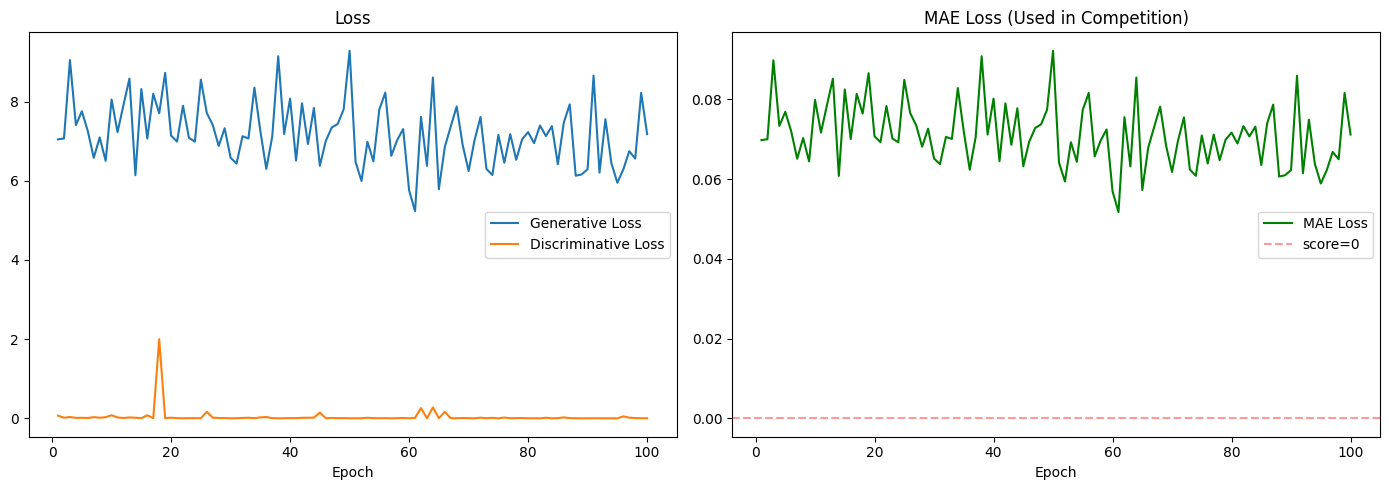

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(results["G_loss"]) + 1)
    
ax1.plot(epochs, results["G_loss"], label="Generative Loss")
ax1.plot(epochs, results["D_loss"],   label="Discriminative Loss")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()
    
ax2.plot(epochs, results["MAE"], label="MAE Loss", color="green")
ax2.axhline(0, color="red", linestyle="--", alpha=0.4, label="score=0")
ax2.set_title("MAE Loss (Used in Competition)"); ax2.set_xlabel("Epoch"); ax2.legend()
    
plt.tight_layout()
plt.show()

# Submission

In [16]:
test_ds = train_ds = ImageDataset(low_res=test_lr_img, is_test=True)
test_dl = DataLoader(test_ds, batch_size=1, shuffle=False)

G.eval()
rows = []

with torch.no_grad():
    for lr, name in test_dl:
        lr = lr.to(device)
        pred = G(lr)[0].permute(1, 2, 0).cpu().numpy()   # HWC, [0,1]
        pred = np.clip(pred * 255.0, 0, 255).astype(np.uint8)
        pixels = " ".join(map(str, pred.reshape(-1).tolist()))
        rows.append([name[0], pixels])

sub = pd.DataFrame(rows, columns=["Id", "Pixels"])
sub.to_csv("submission.csv", index=False)

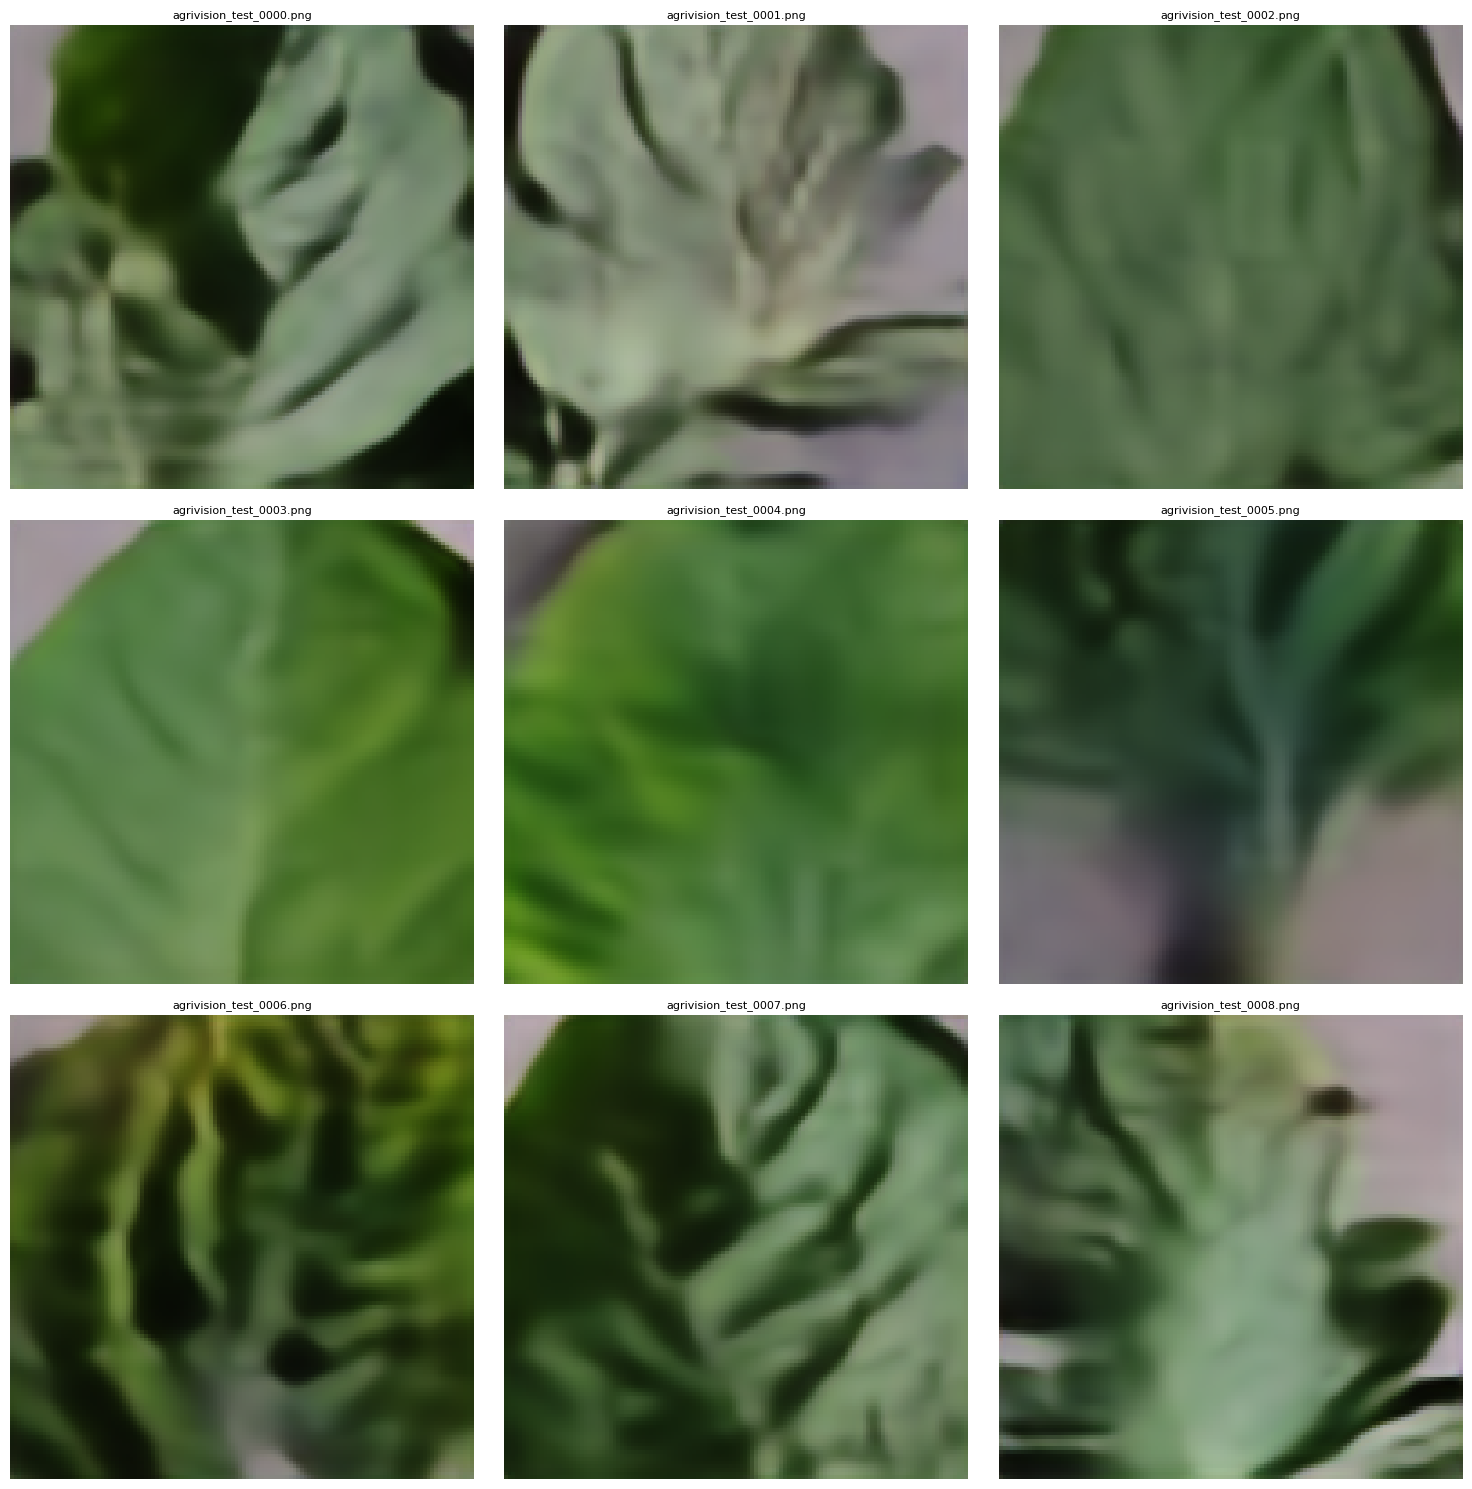

In [17]:
# Visualizing final submission
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
for i, ax in enumerate(axes.flat):
    if i >= len(sub):
        ax.axis('off')
        continue
        
    row = sub.iloc[i]
    pixels = np.fromstring(row['Pixels'], dtype=np.uint8, sep=' ')
    img_array = pixels.reshape(128, 128, 3)
    
    ax.imshow(img_array)
    ax.set_title(f"{row['Id']}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()